In [ ]:
#this dataset is converted from pdf into csv and only for testing

import camelot

# Read all tables from PDF
tables = camelot.read_pdf("../datasets/Market Watch-96.pdf", pages="all", flavor='stream')  # 'stream' works better for aligned text

# Check number of tables extracted
print(f"Total tables found: {len(tables)}")

# Preview first table
tables[0].df.head()

d:\Smart_Agri_System\venv\Lib\site-packages\pypdf\_crypt_providers\_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4
d:\Smart_Agri_System\venv\Lib\site-packages\camelot\parsers\base.py:238: UserWarning: No tables found in table area (49.544, 748.25928, 582.8084, 866.481460841368)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)


Total tables found: 4


,0
0,Jointly produced by:
1,"WFP-World Food Programme, Evidence, Policy and"
2,"Innovation Unit, Nepal"
3,MoALD-Ministry of Agriculture and Livestock De...
4,"(MoALD), Department of Agriculture (DoA), Market"


In [2]:
import pandas as pd

all_tables = [table.df for table in tables]  # list of dataframes
df = pd.concat(all_tables, ignore_index=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,Jointly produced by:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"WFP-World Food Programme, Evidence, Policy and",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Innovation Unit, Nepal",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MoALD-Ministry of Agriculture and Livestock De...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"(MoALD), Department of Agriculture (DoA), Market",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Rename columns to match your format
df.columns = ['date', 'crop', 'market', 'price']

# Remove empty rows
df = df.dropna(how='any')

# Convert price to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows with invalid date/price
df = df.dropna(subset=['date','price'])

ValueError: Length mismatch: Expected axis has 18 elements, new values have 4 elements

In [4]:
import camelot

tables = camelot.read_pdf("../datasets/Market Watch-96.pdf", pages="all", flavor='stream')
print(f"Total tables found: {len(tables)}")

# Preview each table to find the real data table
for i, table in enumerate(tables):
    print(f"\nTable {i} preview:")
    print(table.df.head())

d:\Smart_Agri_System\venv\Lib\site-packages\camelot\parsers\base.py:238: UserWarning: No tables found in table area (49.544, 748.25928, 582.8084, 866.481460841368)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)


Total tables found: 4

Table 0 preview:
                                                   0
0                               Jointly produced by:
1     WFP-World Food Programme, Evidence, Policy and
2                             Innovation Unit, Nepal
3  MoALD-Ministry of Agriculture and Livestock De...
4   (MoALD), Department of Agriculture (DoA), Market

Table 1 preview:
                                                   0
0                                     February 2020†
1                                         HIGHLIGHTS
2  In  February  2020,  retail  prices  of  most ...
3  remained  relatively  stable  or  experienced ...
4          commodities and an overall smooth supply.

Table 2 preview:
       0          1        2  3                     4  5  6   \
0                     Current                                  
1                                                              
2                       price     Change in price (%)*         
3          Commodity     (NRS   

In [5]:
# Pick the likely table
df = tables[2].df  # Table 2 seems like the actual data
df.head(10)         # Inspect the first 10 rows to see headers

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,,,Current,,,,,,,,,,,,,,,
1,,,,,,,,,,,,Current,,,,,,
2,,,price,,Change in price (%)*,,,Average change over,,,,,,Change in price (%)*,,,Average change over,
3,,Commodity,(NRS,,,,,,,,,price,,,,,,
4,Market,,,,,,,,,Market,Commodity,,,,,,,
5,,,per Kg/,,,,,,,,,(NRS per,,,,,,
6,,,,,,,,,,,,Kg/Lt.),,,,,,
7,,,Lt.),1 m,3 m,1 yr,,1m 3m 1yr,,,,,1 m,3 m,1 yr,,1m 3m 1yr,
8,,Major consumer markets,,,,,,,,,,,,,,,,
9,,,,,,,,,,,Coarse rice,42.0,5.0,20.0,13.5,►,▲,►


In [6]:
# Assume tables[2] contains this data
df = tables[2].df

# Skip first 9 rows of headers
df = df[9:].reset_index(drop=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,,,,,,,,,,,Coarse rice,42.0,5.0,20.0,13.5,►,▲,►
1,,Coarse rice,47.0,0.0,0.0,0.0,►,►,►,,,,,,,,,
2,,,,,,,,,,,Wheat flour,46.0,0.0,4.5,4.5,►,►,►
3,,,60.0,0.0,0.0,25.0,►,►,▲,,,,,,,,,
4,,Wheat flour,,,,,,,,,Soybean oil,147.0,0.0,11.4,7.3,►,▲,►


In [4]:
# Adjust based on your column index
df = df[[1, 2, 3, 4]]  # crop + 3 markets
df.columns = ['crop', 'Kathmandu', 'Biratnagar', 'Hetauda']
df.head()

NameError: name 'df' is not defined

In [3]:
df_long = df.melt(id_vars=['crop'], 
                  value_vars=['Kathmandu', 'Biratnagar', 'Hetauda'], 
                  var_name='market', 
                  value_name='price')

# Convert price to numeric
df_long['price'] = pd.to_numeric(df_long['price'], errors='coerce')

# Drop rows with missing prices
df_long = df_long.dropna(subset=['price'])

NameError: name 'df' is not defined

In [9]:
df_long['date'] = pd.to_datetime('2020-02-01')
df_long = df_long[['date','crop','market','price']]
df_long.head()

,date,crop,market,price
1,2020-02-01,Coarse rice,Kathmandu,47.0
3,2020-02-01,,Kathmandu,60.0
5,2020-02-01,Soybean oil,Kathmandu,140.0
7,2020-02-01,Chicken,Kathmandu,400.0
9,2020-02-01,Broken lentil,Kathmandu,110.0


In [11]:
df_long.to_csv("../datasets/market_prices_feb2020.csv", index=False)

NameError: name 'df_long' is not defined

In [15]:
#Loading the datasets and importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib

data = pd.read_csv("../datasets/market_prices_feb2020.csv")
data.head()



,date,crop,market,price
0,2020-02-01,Coarse rice,Kathmandu,47.0
1,2020-02-01,NaN,Kathmandu,60.0
2,2020-02-01,Soybean oil,Kathmandu,140.0
3,2020-02-01,Chicken,Kathmandu,400.0
4,2020-02-01,Broken lentil,Kathmandu,110.0


In [16]:
data = data.dropna(subset=['crop'])  # remove NaN crops

# Keep only crop-related items
valid_crops = ['rice','wheat','maize','lentil']

data = data[data['crop'].str.lower().str.contains('|'.join(valid_crops))]

In [18]:
data.head()

,date,crop,market,price
0,2020-02-01,Coarse rice,Kathmandu,47.0
4,2020-02-01,Broken lentil,Kathmandu,110.0
6,2020-02-01,Coarse rice,Kathmandu,55.0
7,2020-02-01,Wheat flour,Kathmandu,60.0
12,2020-02-01,Coarse rice,Kathmandu,55.0


In [19]:
data.columns

Index(['date', 'crop', 'market', 'price'], dtype='str')

In [20]:
data.isnull().sum()

date      0
crop      0
market    0
price     0
dtype: int64

In [8]:
data.shape

(144, 4)

In [21]:
data.info()

<class 'pandas.DataFrame'>
Index: 66 entries, 0 to 142
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    66 non-null     str    
 1   crop    66 non-null     str    
 2   market  66 non-null     str    
 3   price   66 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.6 KB


In [2]:
#Importing libraries and loading different 3 datasets
# importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

import joblib


# Load datasets
data_kalimati1 = pd.read_csv("../datasets/kalimati_2013_2021.csv")
#data_kalimati2 = pd.read_csv("../datasets/kalimati_2021_2023.csv")
data_kalimati2 = pd.read_csv("../datasets/kalimati_2021_2023.csv", header=None)
data_india = pd.read_csv("../datasets/indian_crop_price.csv")
data_local = pd.read_csv("../datasets/nepal_local_crop_price.csv")





In [5]:
#assigning proper columns name of kalimati2 dataset
data_kalimati2.columns = ['crop','date','unit','min_price','max_price','price']

In [6]:
#cleaning it properly kalimati2 dataset
data_kalimati2['market'] = 'Kalimati'
data_kalimati2['country'] = 'Nepal'

# Keep required columns
data_kalimati2 = data_kalimati2[['date','crop','market','price','country']]

In [7]:
#converting date format
data_kalimati2['date'] = pd.to_datetime(data_kalimati2['date'], errors='coerce')

In [8]:
#merging with first kalimati1 dataset
data_kalimati = pd.concat([data_kalimati1, data_kalimati2], ignore_index=True)

In [9]:
data_kalimati1.head()


,_id,SN,Commodity,Date,Unit,Minimum,Maximum,Average
0,1,0,Tomato Big(Nepali),2013-06-16T00:00:00,Kg,35,40,37.5
1,2,1,Tomato Small(Local),2013-06-16T00:00:00,Kg,26,32,29.0
2,3,2,Potato Red,2013-06-16T00:00:00,Kg,20,21,20.5
3,4,3,Potato White,2013-06-16T00:00:00,Kg,15,16,15.5
4,5,4,Onion Dry (Indian),2013-06-16T00:00:00,Kg,28,30,29.0


In [10]:
data_kalimati2.head()

,date,crop,market,price,country
0,2021-01-05,Tomato Big(Nepali),Kalimati,55,Nepal
1,2021-01-05,Tomato Big(Indian),Kalimati,55,Nepal
2,2021-01-05,Tomato Small(Local),Kalimati,32.5,Nepal
3,2021-01-05,Tomato Small(Tunnel),Kalimati,32.5,Nepal
4,2021-01-05,Tomato Small(Indian),Kalimati,42.5,Nepal


In [11]:
data_india.head()

,State,Crop,CostCultivation,CostCultivation2,Production,Yield,Temperature,RainFall Annual,Price
0,Uttar Pradesh,ARHAR,9794.05,9800.25,1941.55,9.83,28.96,3373.2,19589.10
1,Karnataka,ARHAR,10593.15,10594.15,2172.46,7.47,29.22,3520.7,21187.30
2,Gujarat,ARHAR,13468.82,13469.82,1898.30,9.59,28.47,2957.4,26938.64
3,Andhra Pradesh,ARHAR,17051.66,17052.66,3670.54,6.42,28.49,3079.6,34104.32
4,Maharashtra,ARHAR,17130.55,17131.55,2775.80,8.72,28.30,2566.7,34262.10


In [12]:
data_local.head()

,date,crop,market,price
0,2020-02-01,Coarse rice,Kathmandu,47.0
1,2020-02-01,NaN,Kathmandu,60.0
2,2020-02-01,Soybean oil,Kathmandu,140.0
3,2020-02-01,Chicken,Kathmandu,400.0
4,2020-02-01,Broken lentil,Kathmandu,110.0


In [13]:
#standardize both kalimati datasets columns
def clean_kalimati(df):
    df = df.copy()
    
    df.rename(columns={
        'Commodity': 'crop',
        'Date': 'date',
        'Average': 'price'
    }, inplace=True)
    
    df['market'] = 'Kalimati'
    df['country'] = 'Nepal'
    
    return df[['date','crop','market','price','country']]


data_kalimati1 = clean_kalimati(data_kalimati1)
data_kalimati2 = clean_kalimati(data_kalimati2)

# Merge both Kalimati datasets
data_kalimati = pd.concat([data_kalimati1, data_kalimati2], ignore_index=True)

In [14]:
#printing both kalimati datasets columns
print(data_kalimati1.columns)
print(data_kalimati2.columns)

Index(['date', 'crop', 'market', 'price', 'country'], dtype='str')
Index(['date', 'crop', 'market', 'price', 'country'], dtype='str')


In [ ]:
#standardize indian datasets
data_india = data_india.copy()

# Adjust based on your CSV columns
data_india.rename(columns={
    'Crop': 'crop',
    'Date': 'date',
    'Price': 'price'
}, inplace=True)

# Convert INR → NPR
data_india['price'] = data_india['price'] * 1.6

data_india['market'] = 'IndiaMarket'
data_india['country'] = 'India'

data_india = data_india[['date','crop','market','price','country']]

In [15]:
data_india.columns

Index(['State', 'Crop', 'CostCultivation', 'CostCultivation2', 'Production',
       'Yield', 'Temperature', 'RainFall Annual', 'Price'],
      dtype='str')

In [16]:
data_local = data_local.copy()

# Remove missing crops
data_local = data_local.dropna(subset=['crop'])

# Keep only relevant crops
valid_crops = ['rice','wheat','maize','lentil']
data_local = data_local[data_local['crop'].str.lower().str.contains('|'.join(valid_crops))]

data_local['country'] = 'Nepal'

data_local = data_local[['date','crop','market','price','country']]

In [17]:
data_local.columns

Index(['date', 'crop', 'market', 'price', 'country'], dtype='str')

In [18]:
# Combine all datasets
df = pd.concat([data_kalimati, data_local], ignore_index=True)

# Convert date format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove invalid rows
df = df.dropna(subset=['date','price','crop'])

# Reset index
df = df.reset_index(drop=True)

df.head()

,date,crop,market,price,country
0,2013-06-16,Tomato Big(Nepali),Kalimati,37.5,Nepal
1,2013-06-16,Tomato Small(Local),Kalimati,29.0,Nepal
2,2013-06-16,Potato Red,Kalimati,20.5,Nepal
3,2013-06-16,Potato White,Kalimati,15.5,Nepal
4,2013-06-16,Onion Dry (Indian),Kalimati,29.0,Nepal


In [19]:
print("Shape:", df.shape)
print(df['country'].value_counts())
print(df['crop'].nunique())

Shape: (242485, 5)
country
Nepal    242485
Name: count, dtype: int64
135


In [20]:
df_price = df.copy()
df_price.info()
df_price.describe()
df_price['crop'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 242485 entries, 0 to 242484
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   date     242485 non-null  datetime64[us]
 1   crop     242485 non-null  str           
 2   market   242485 non-null  str           
 3   price    242485 non-null  object        
 4   country  242485 non-null  str           
dtypes: datetime64[us](1), object(1), str(3)
memory usage: 9.3+ MB


crop
Cauli Local             3216
Ginger                  3216
Cabbage(Local)          3213
Chilli Dry              3213
Raddish White(Local)    3212
                        ... 
Water Melon(Dotted)       53
Maize                     24
Sweet Lime                20
Sarifa                    18
Musk Melon                10
Name: count, Length: 135, dtype: int64

In [23]:
#checking the data values of Item column
df["crop"].unique()

<StringArray>
[  'tomato big(nepali)',  'tomato small(local)',           'potato red',
         'potato white',   'onion dry (indian)',        'carrot(local)',
       'cabbage(local)',          'cauli local',          'raddish red',
 'raddish white(local)',
 ...
       'cabbage(terai)',   'cauli local(jyapu)', 'pointed gourd(terai)',
        'grapes(black)',                 'kiwi',      'mango(calcutte)',
        'mango(chousa)',               'sarifa',              'avocado',
                 'amla']
Length: 135, dtype: str

In [22]:
#df["crop"] = df["crop"].str.lower()
df['crop'] = df['crop'].str.lower().str.strip()

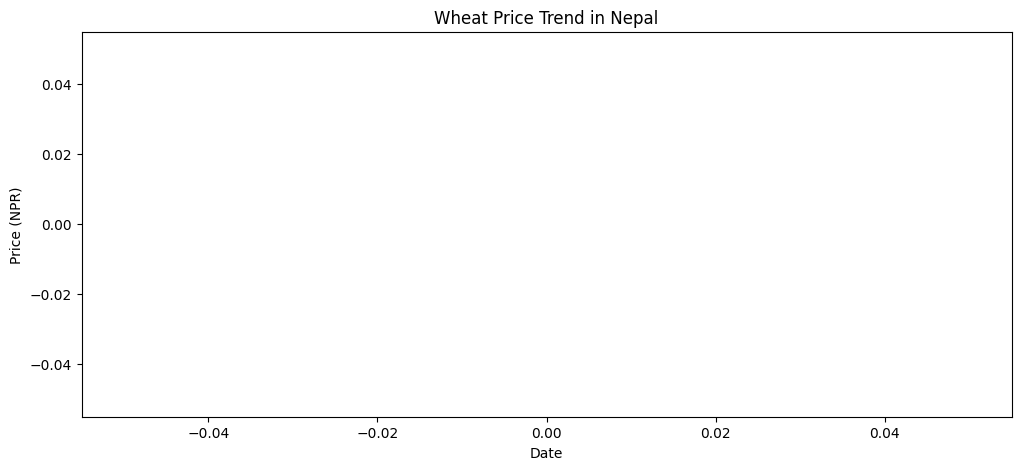

In [97]:
#EDA: time-series plot per crop

# Example: Wheat price trend
wheat = df_price[df_price['crop'].str.lower() == 'wheat']
wheat = wheat.sort_values('date')

plt.figure(figsize=(12,5))
sns.lineplot(data=wheat, x='date', y='price')
plt.title("Wheat Price Trend in Nepal")
plt.xlabel("Date")
plt.ylabel("Price (NPR)")
plt.show()

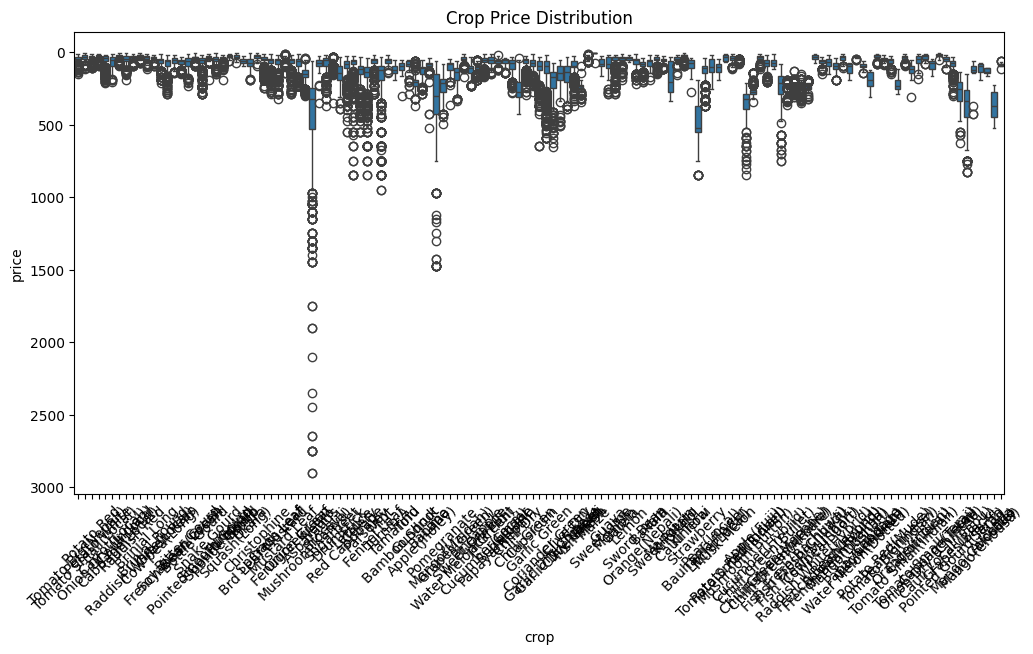

In [ ]:
#crop price distribution
plt.figure(figsize=(12,6))
sns.boxplot(x='crop', y='price', data=df_price)
plt.title("Crop Price Distribution")
plt.xticks(rotation=45)
plt.show()

In [99]:
df_price = df_price.sort_values(['crop','date'])
df_price['price_lag_1'] = df_price.groupby('crop')['price'].shift(1)
df_price['price_lag_7'] = df_price.groupby('crop')['price'].shift(7)
df_price['price_lag_30'] = df_price.groupby('crop')['price'].shift(30)

In [100]:
df_price['price_roll_7'] = df_price.groupby('crop')['price'].transform(lambda x: x.rolling(7).mean())
df_price['price_roll_30'] = df_price.groupby('crop')['price'].transform(lambda x: x.rolling(30).mean())

In [101]:
df_price['month'] = df_price['date'].dt.month
df_price['day'] = df_price['date'].dt.day
df_price['weekday'] = df_price['date'].dt.weekday

In [102]:
df_price = df_price.dropna(subset=['price_lag_1','price_lag_7','price_lag_30','price_roll_7','price_roll_30'])

In [103]:
#from sklearn.model_selection import train_test_split

features = ['price_lag_1','price_lag_7','price_lag_30','price_roll_7','price_roll_30','month','day','weekday']
target = 'price'

X = df_price[features]
y = df_price[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

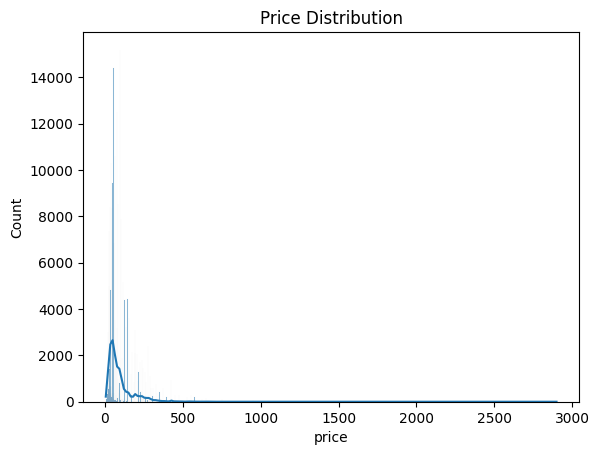

In [ ]:
#visualization of price distribution
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

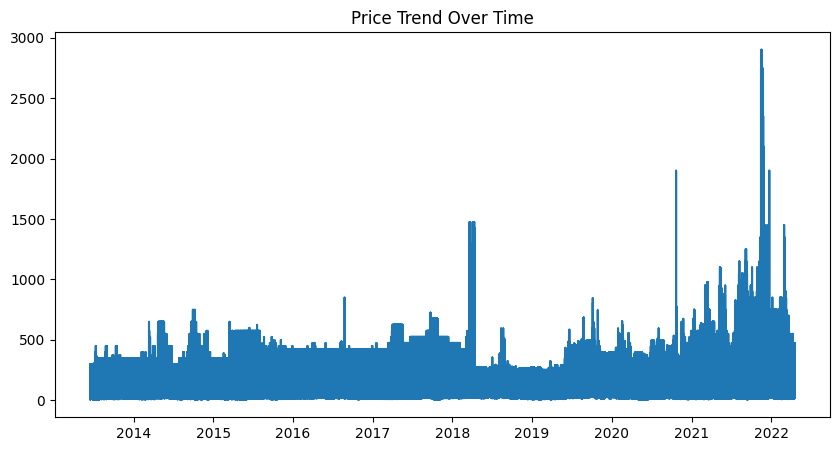

In [ ]:
#visualization of price over time
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['price'])
plt.title("Price Trend Over Time")
plt.show()

In [ ]:
#visualization of price by crop
sns.boxplot(x='crop', y='price', data=df)
plt.xticks(rotation=90)
plt.title("Price by Crop")
plt.show()

In [ ]:
#features selection or engineering
# Time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Encode categorical variables
df = pd.get_dummies(df, columns=['crop','market','country'])

# Features & target
X = df.drop(['date','price'], axis=1)
y = df['price']

In [ ]:
#train and test splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [29]:
#Evaluation and comparison of different models
def evaluate(name, model):
    y_pred = model.predict(X_test)
    print(name)
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))
    print("-----------")

evaluate("Linear Regression", lr)
evaluate("Random Forest", rf)
evaluate("Gradient Boosting", gb)

Linear Regression
RMSE: 54.52915889161361
R2: 0.6630436359848907
-----------
Random Forest
RMSE: 22.114677990215103
R2: 0.9445786238112193
-----------
Gradient Boosting
RMSE: 52.90775838398091
R2: 0.6827842159942745
-----------


In [ ]:
#saving the best model
final_model = rf  # best random forest

joblib.dump(final_model, "../ml_models/market_prediction/price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("LR RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RF RMSE:", mean_squared_error(y_test, y_pred_rf, squared=False))

TypeError: got an unexpected keyword argument 'squared'